note : 
 I wrote all the code myself.
 I used Microsoft Copilot to help explain some ideas
 and to organize formatting (spacing and line order, Functions), and help me structure the report...
 All logic and tasks come directly from the ML Foundations course slides.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
rows,cols= df.shape
rows,cols

(1338, 7)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
df["charges"] = pd.to_numeric(df["charges"], errors="coerce")
#يحول تحويل القيم في العمود إلى أرقام


In [6]:
df.isnull().sum()
# No missing values found — no dropping or imputation needed

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()
df = df.drop_duplicates()
# يشيل التكرارات 

In [8]:
df.duplicated().sum()
# now dataset is clean


np.int64(0)

I chose the charges column because it has a heavy right tail and clear extreme values that can distort model performance, making it the best candidate for outlier detection and capping.


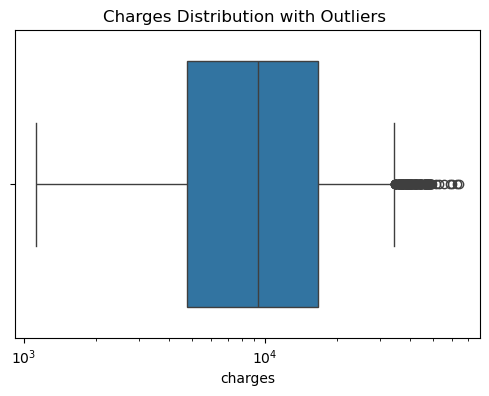

63770.42801

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["charges"])
plt.xscale("log")  
plt.title("Charges Distribution with Outliers ")
plt.show()
df["charges"].max()


In [10]:
upper = df["charges"].quantile(0.99)
df["charges"] = df["charges"].clip(upper=upper)

df["charges"].max()


48537.79687800001

In [11]:
'''
1-48537.79687800001
2-48525.8508849888
Obvious change
'''

'\n1-48537.79687800001\n2-48525.8508849888\nObvious change\n'

In [12]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    df["charges"] = pd.to_numeric(df["charges"], errors="coerce")

    df = df.drop_duplicates()

    upper = df["charges"].quantile(0.99)
    df["charges"] = df["charges"].clip(upper=upper)

    return df


In [13]:
# Some AI assistance was used in this idea.
assert df.notnull().all().all()
assert (df["charges"] > 0).all()
assert df.shape[1] == 7